# Predict the pedestal using EPEDNN-SC loop for ARC baseline scenario

In [1]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys
from pathlib import Path
import urllib.request # needed for geqdsk import
ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


In [2]:
# Import the ARC baseline scenario geqdsk if it does not currently exist
_ZENODO = 'https://zenodo.org/records/19498373/files'

def _fetch(filename):
    if not os.path.exists(filename):
        print(f'Downloading {filename} from Zenodo...', end=' ', flush=True)
        urllib.request.urlretrieve(f'{_ZENODO}/{filename}?download=1', filename)
        print('done.')

mhd_fp = 'geqdsk-ARCv3a'
_fetch(mhd_fp) # places geqdsk file in the current directory

Loaded ne: 32 points (ne [10^20 particles/m^3])
Loaded Te: 43 points (Te [keV])


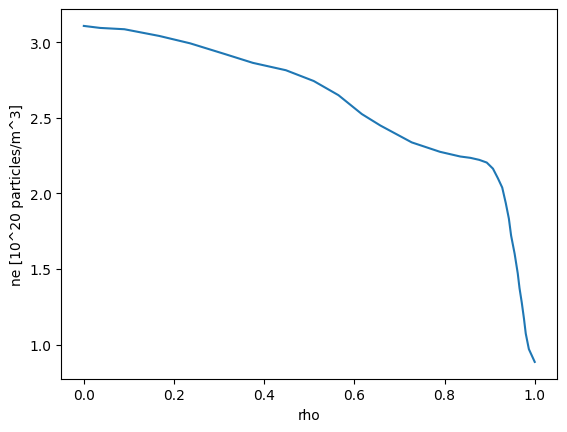

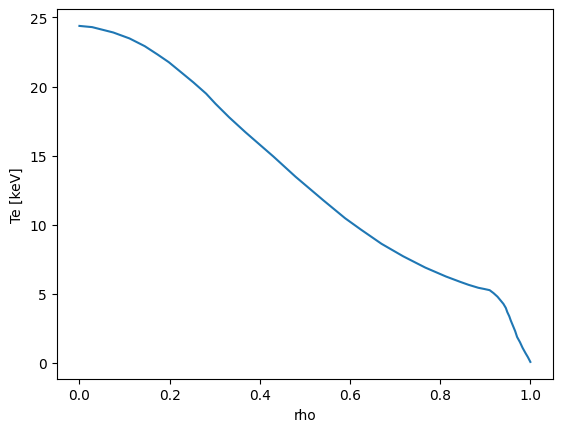

In [3]:
# Import reference profiles digitized from Howard et al. 2026 Fig. 4

def load_digitized_profile(filepath):
    """Load rho and profile data from a Web Plot Digitizer export.

    Parameters
    ----------
    filepath : str or Path
        Path to an ARC_*_extracted.txt file.

    Returns
    -------
    rho : ndarray
        Normalized radial coordinate.
    profile : ndarray
        ne in 10^20 m^-3 or Te in keV, depending on the file.
    quantity : str
        'ne' or 'Te'.
    units : str
        Unit string parsed from the file header.
    """
    filepath = Path(filepath)
    data_lines = []
    quantity = None
    units = None

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.lower().startswith('rho,'):
                header = line
                if 'ne' in header.lower():
                    quantity = 'ne'
                elif 'te' in header.lower():
                    quantity = 'Te'
                units = header.split(',', 1)[1].strip()
                continue
            if quantity is not None:
                parts = [part.strip() for part in line.split(',')]
                if len(parts) == 2:
                    try:
                        data_lines.append((float(parts[0]), float(parts[1])))
                    except ValueError:
                        pass

    if not data_lines:
        raise ValueError(f'No profile data found in {filepath}')

    data = np.array(data_lines)
    sort_idx = np.argsort(data[:, 0])
    data = data[sort_idx]
    return data[:, 0], data[:, 1], quantity, units


ne_fp = 'ARC_ne_extracted.txt'
Te_fp = 'ARC_Te_extracted.txt'

rho_ne, ne_ref, _, ne_units = load_digitized_profile(ne_fp)
rho_Te, Te_ref, _, Te_units = load_digitized_profile(Te_fp)

np.save('ARC_ne_extracted.npy', {'rho': rho_ne, 'ne': ne_ref, 'units': ne_units})
np.save('ARC_Te_extracted.npy', {'rho': rho_Te, 'Te': Te_ref, 'units': Te_units})

print(f'Loaded ne: {len(rho_ne)} points ({ne_units})')
print(f'Loaded Te: {len(rho_Te)} points ({Te_units})')

fig,ax = plt.subplots()
ax.plot(rho_ne, ne_ref, label='ne')
ax.set_xlabel('rho')
ax.set_ylabel('ne [10^20 particles/m^3]')

fig1,ax1 = plt.subplots()
ax1.plot(rho_Te, Te_ref, label='Te')
ax1.set_xlabel('rho')
ax1.set_ylabel('Te [keV]')

manual_profs = {
    'ne': ne_ref,
    'Te': Te_ref,
    'rho_ne': rho_ne,
    'rho_Te': rho_Te
}


In [4]:
# Parameters for model #

# Output directory
out_dir = 'ARC_output_logs'

# Scan parameters
x_res = 20
free_params = {
    'alpha_crit': 1,
    'C_KBM': 0.1,
    'De_chie_etg': 0.1,
    'nFC_x0': 3.16228e15,
    'ncx_x0_ratio': 1
}
eped_tol_max = 1e-5
eped_iter_max = 1000
EPEDNN_core = 'previous T, stiched ne'
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_relax = 1.0

verbose = True
verbose_sc = True

S_i: [1.27179177e-14 1.27179177e-14 1.27179177e-14 1.27179177e-14
 1.27179177e-14 1.27179177e-14 1.27179177e-14 1.27179177e-14
 1.27179177e-14 1.27179177e-14 1.27179177e-14 1.27179177e-14
 1.27179177e-14 1.27179177e-14 1.27179177e-14 1.27179177e-14
 1.27179177e-14 1.29043642e-14 1.35287809e-14 1.41671481e-14
 1.48404735e-14 1.54542828e-14 1.58655301e-14 1.61101774e-14
 1.63677993e-14 1.64749283e-14 1.65843248e-14 1.68673269e-14
 1.72286232e-14 1.76163500e-14 1.80341494e-14 1.85650889e-14
 1.91507734e-14 1.98019642e-14 2.05320674e-14 2.17492939e-14
 2.29175919e-14 2.47242047e-14 2.68420500e-14 2.97210790e-14
 3.39864089e-14 3.92340760e-14 4.59976627e-14]
S_cx: [6.15903859e-14 6.17597615e-14 6.25160262e-14 6.33549731e-14
 6.44445194e-14 6.56172037e-14 6.67060207e-14 6.82968566e-14
 6.95527702e-14 7.11434238e-14 7.25662516e-14 7.44914631e-14
 7.65843181e-14 8.00168628e-14 8.28631565e-14 8.62121073e-14
 8.87239344e-14 9.03151350e-14 9.23252166e-14 9.40846989e-14
 9.55929010e-14 9.62477647e

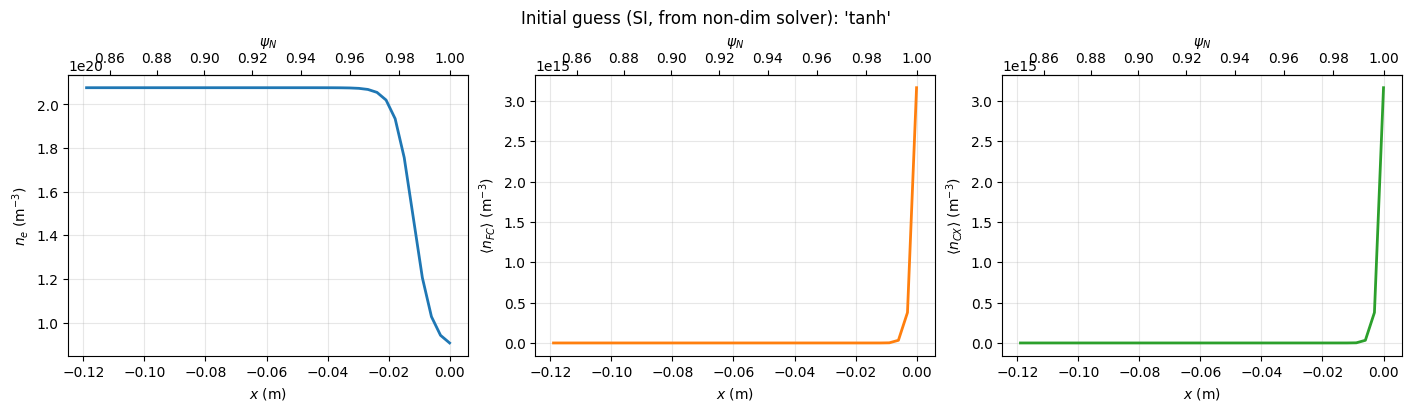

[picard] it   1: |dne|_rel = 4.366e-01, alpha_bar = 1.3206, frac(alpha>crit) = 0.17, KBM ON
[picard] it   2: |dne|_rel = 5.143e-03, alpha_bar = 1.3213, frac(alpha>crit) = 0.17, KBM ON
[picard] it   3: |dne|_rel = 7.653e-06, alpha_bar = 1.3212, frac(alpha>crit) = 0.17, KBM ON
[picard] it   4: |dne|_rel = 0.000e+00, alpha_bar = 1.3212, frac(alpha>crit) = 0.17, KBM ON
[nondim] hat residuals solved.
  hat_n_e  in [9.800e-01, 1.735e+00]
  hat_n_FC in [-1.252e-04, 1.284e-04]
  hat_n_CX in [-9.587e-05, 6.698e-05]
betat: [0.00825789], a: 1.5589442500000001, bt: [11.34364597], Ip: -12.0
betan: [1.21694598]
Pedestal height: 0.14237455796584808 MPa, Pedestal width: 0.048639011110940135 (psi_N)
  Te_ped = 4625.3 eV, T_sep = 85.6 eV (ne_ped = 9.606e+19 m^-3, psi_ped = 0.9514, Delta = 0.0486)
  psi_N_inner_boundary_new = 0.9514


KeyError: 'rho_Te'

┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


In [6]:
# Model run
ped_wid, ped_h_out, gfile_pres, gfile_pres_grid = profiles_loop_solve(
    MHD_FP = mhd_fp,
    kprof_loc = 'manual rho grid',
    manual_profs = manual_profs,
    P_tot_e = ( 21.5 + 0.8 + 227 ) * 0.5 * 1e6, # table 4 of Hillesheim et al. 2026
    out_dir = out_dir,
    x_res = x_res,
    free_params = free_params,
    eped_tol_max = eped_tol_max,
    eped_iter_max = eped_iter_max,
    kbm_gate_eps = kbm_gate_eps,
    EPEDNN_core = EPEDNN_core,
    kbm_treatment = kbm_treatment,
    picard_gate_mode = picard_gate_mode,
    picard_relax = picard_relax,
    ig = 'fix',
    epednn_model = 'EPED1',
    verbose = verbose,
    verbose_sc = verbose_sc
)

In [ ]:
# Model output #

def pres_pred(ped_wid, gfile_pres, gfile_pres_grid):
    """
    Calculate pedestal pressure from pedestal width and MHD equilibrium file.
    """
    psiN_top = 1 - ped_wid
    return np.interp(psiN_top, gfile_pres_grid, gfile_pres)


p_gfile = pres_pred(ped_wid, gfile_pres, gfile_pres_grid)
out_dict = {
    'mhd_fp': mhd_fp,
    'profiles': manual_profs,
    'ped_h': ped_h_out,
    'ped_wid': ped_wid,
    'p_gfile': p_gfile,
}
np.save(output_dir+'/ARC_pedestal_prediction.npy', out_dict)